  ## HDFS LogAnomaly Anomaly Detection Experiment

  This experiment focuses on training and evaluating the **LogAnomaly** model (LSTM + Multi-Head
  Attention) for **anomaly detection** on the HDFS log dataset.

  ### I. Dataset and Source

  * **Dataset:** HDFS (LogHub preprocessed)
  * **Source Citation:** Wei Xu et al. (SOSP 2009), Jieming Zhu et al. (ISSRE 2023)

  ### II. Model: LogAnomaly (LSTM + Attention)

  * **Architecture:** **LSTM with Multi-Head Attention mechanism**
  * **Key Features:**
      * Multi-Head Attention for long-range dependencies
      * Residual connections and Layer Normalization
      * Semantic embeddings support
  * **Hyperparameters:**
      * `embedding_dim`: 64
      * `hidden_dim`: 128
      * `num_layers`: 2
      * `dropout`: 0.3
      * `n_heads`: 4
      * `use_attention`: True


  ### III. Task and Evaluation

  * **Task:** **Next-Event Prediction** for Sequence-Based Anomaly Detection.
      * Anomalies detected using **Top-k Prediction** criteria.
      * `top_k`: 4
  * **Evaluation Metrics:** Accuracy, Precision, Recall, F1 Score, and AUC.

  ### IV. Data Flow and Training

  #### A. Preprocessing
  * **Tokenization:** Log events are tokenized and mapped to **integer IDs** via a vocabulary.
  * **Sequencing:** Log sequences are padded to the **95th percentile length** using a padding value of
  **0**.
  * **Data Split:**
      * Train: 70%
      * Validation: 15%
      * Test: 15%

  #### B. Training
  * **Batch Size:** 64
  * **Learning Rate:** 0.001
  * **Epochs:** Up to 50, with **Early Stopping** (`patience=20`).
  * **Device:** Auto-detected (mps/cpu).

  ### V. Artifacts

  * **Model Checkpoint:** `../mdls/loganomaly_checkpoint.pt`
  * **Results:** `../results/hdfs_loganomaly_results.json`
  * **Visualizations:** `../figures/loganomaly/`

  ### VI. Comparison with DeepLog

  LogAnomaly extends DeepLog with:
  1. **Multi-Head Attention** to capture long-range dependencies
  2. **Residual connections** for better gradient flow
  3. **Layer Normalization** for stable training
  4. **Optional semantic embeddings** for better event representation

### 1. Setup and Imports

In [3]:
# Core imports
import numpy as np
import torch
import sys
from pathlib import Path
# Add project root to Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Import modules
from src.data.dataset import create_data_loaders
from src.models.loganomaly import LogAnomalyModel
from src.engine.trainer import LogSeqTrainer
from src.utils.metrics import evaluate_model, print_metrics, save_experiment_results
from src.utils.data_loader import create_train_val_test_split, filter_normal_samples, load_loghub
from src.utils.visualizer import UniversalAnomalyVisualizer
from src.utils.seed import seed_everything

### 2. Load and Prepare Data

In [4]:
# Define paths
DATA_DIR = '../../data/hdfs/preprocessed'
seed_everything(42)  # For reproducibility

In [5]:
# Load HDFS data using the utility function 
X, y, vocab = load_loghub(DATA_DIR)

vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Events: {sorted(vocab.keys())[:10]}")

INFO:src.utils.data_loader:Loading data from LogHub preprocessing: ../../data/hdfs/preprocessed
INFO:src.utils.data_loader:Loaded data:
INFO:src.utils.data_loader:  - Sequences: (575061,)
INFO:src.utils.data_loader:  - Labels: (575061,)
INFO:src.utils.data_loader:  - Normal: 558223, Anomaly: 16838
INFO:src.utils.data_loader:  - Loaded vocabulary: 29 events


Vocab size: 29
Events: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18']


In [32]:
# Split data (70/15/15)
splits = create_train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, random_state=42)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = splits['train'], splits['val'], splits['test']

# Filter to keep only normal samples for semi-supervised training
X_train, y_train = filter_normal_samples(X_train, y_train, verbose=True)

INFO:src.utils.data_loader:Splitting data: train=0.7, val=0.15, test=0.15
INFO:src.utils.data_loader:Split complete:
INFO:src.utils.data_loader:  - Train: 402542 samples (11786 anomalies)
INFO:src.utils.data_loader:  - Val:   86259 samples (2526 anomalies)
INFO:src.utils.data_loader:  - Test:  86260 samples (2526 anomalies)
INFO:src.utils.data_loader:======================================================================
INFO:src.utils.data_loader:FILTERING TRAINING DATA FOR SEMI-SUPERVISED LEARNING
INFO:src.utils.data_loader:======================================================================
INFO:src.utils.data_loader:Original training size: 402542 samples
INFO:src.utils.data_loader:  Normal samples: 390,756 (97.07%)
INFO:src.utils.data_loader:  Anomaly samples: 11,786 (2.93%)
INFO:src.utils.data_loader:
Filtered training size: 390,756 samples (NORMAL ONLY)
INFO:src.utils.data_loader:Removed 11,786 anomalies from training set
INFO:src.utils.data_loader:✓ Training data is now pure no

In [33]:
# Convert strings to integers using the loaded vocab
def convert_to_ids(sequences, vocab):
    return [[vocab[event] for event in seq] for seq in sequences]

X_train_ids = convert_to_ids(X_train, vocab)
X_val_ids = convert_to_ids(X_val, vocab)
X_test_ids = convert_to_ids(X_test, vocab)

In [34]:
# Pad sequences (integers)
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = int(np.percentile([len(s) for s in X_train_ids], 95))

X_train_padded = pad_sequences(X_train_ids, maxlen=max_len, padding='post', value=0)
X_val_padded = pad_sequences(X_val_ids, maxlen=max_len, padding='post', value=0)
X_test_padded = pad_sequences(X_test_ids, maxlen=max_len, padding='post', value=0)

print(f"Max length: {max_len}")
print(f"Train shape: {X_train_padded.shape}")

Max length: 28
Train shape: (390756, 28)


In [35]:
# Get optimal dataloader kwargs
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
loader_kwargs = LogSeqTrainer.get_optimal_dataloader_kwargs(device)
loader_kwargs

{'pin_memory': False, 'num_workers': 4}

In [36]:
# Create data loaders
batch_size = 64
train_loader, val_loader, test_loader = create_data_loaders(
    X_train_padded, y_train,
    X_val_padded, y_val,
    X_test_padded, y_test,
    batch_size=batch_size,
    **loader_kwargs
)

### 3. Create LogAnomaly Model

LogAnomaly enhances DeepLog with:
- **Multi-Head Attention** (4 heads)
- **Residual connections**
- **Layer Normalization**
- **Semantic Embeddings** (pre-trained from log templates)

In [37]:
#  Load the pre-computed embeddings
semantic_vectors = torch.load(f'{DATA_DIR}/semantic_embeddings.pt')
emb_dim = semantic_vectors.shape[1] 
print(f"Loaded semantic embeddings with dim: {emb_dim}")

Loaded semantic embeddings with dim: 384


In [ ]:
# Create LogAnomaly model
model = LogAnomalyModel(
    vocab_size=vocab_size,
    embedding_dim=emb_dim,  
    hidden_dim=128,
    num_layers=2,
    dropout=0.3,
    use_attention=True, 
    n_heads=4, 
    semantic_embeddings=semantic_vectors 
)

In [39]:
# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Embedding dimension: {emb_dim}")
print(f"  Attention enabled: {model.use_attention}")
print(f"  Semantic embeddings: {'✓ Loaded' if semantic_vectors is not None else '✗ Random init'}")


Model Architecture:
  Total parameters: 1,466,013
  Trainable parameters: 1,466,013
  Embedding dimension: 384
  Attention enabled: True
  Semantic embeddings: ✓ Loaded


### 4. Train LogAnomaly

In [40]:
# Train
learning_rate = 0.001
patience = 10

print(f"Training on device: {device}")

trainer = LogSeqTrainer(model, device=device, learning_rate=learning_rate)

history = trainer.fit(
    train_loader, val_loader,
    num_epochs=50,
    early_stopping_patience=patience,
    print_every=5  # Print every 5 epochs
)

Training on device: mps


Training: 100%|██████████| 6106/6106 [01:22<00:00, 73.88it/s]



Epoch 1/50 - 89.92s
  Train Loss: 0.2268
  Val Loss:   0.2407
  ✓ New best model (val_loss: 0.2407)


Training: 100%|██████████| 6106/6106 [01:23<00:00, 73.28it/s]



Epoch 5/50 - 89.97s
  Train Loss: 0.2106
  Val Loss:   0.2363
  ✓ New best model (val_loss: 0.2363)


...


Epoch 10/50 - 90.61s
  Train Loss: 0.2096
  Val Loss:   0.2357
  No improvement (4/10)


Training: 100%|██████████| 6106/6106 [01:22<00:00, 74.31it/s]



Epoch 15/50 - 88.53s
  Train Loss: 0.2093
  Val Loss:   0.2369
  No improvement (9/10)


Training: 100%|██████████| 6106/6106 [01:21<00:00, 75.14it/s]



Early stopping triggered after 16 epochs

✓ Loaded best model (val_loss: 0.2353)
Total training time: 1424.40s


  ### 5. Evaluation

  Evaluate using top-k prediction 

In [45]:
# Evaluate
# Capture predictions, true labels, AND anomaly scores from the loader
top_k = 4
predictions, true_labels, anomaly_scores = trainer.detect_anomalies(
    test_loader,
    top_k=top_k,
    return_scores=True
)

metrics = evaluate_model(predictions, true_labels) 
print_metrics(metrics)

Detecting anomalies: 100%|██████████| 1348/1348 [00:11<00:00, 117.36it/s]


EVALUATION METRICS
Accuracy:  0.9861 (98.61%)
Precision: 0.8427
Recall:    0.6449
F1-Score:  0.7307

Confusion Matrix:
              Predicted
              Normal  Anomaly
Actual Normal    83430      304
       Anomaly     897     1629


### 6. Visualizations

Generate comprehensive visualizations including:
1. Training history
2. Confusion matrix
3. Anomaly score distribution
4. ROC curve
5. Precision-Recall curve

✓ Saved: ../figures/loganomaly/training_history.png


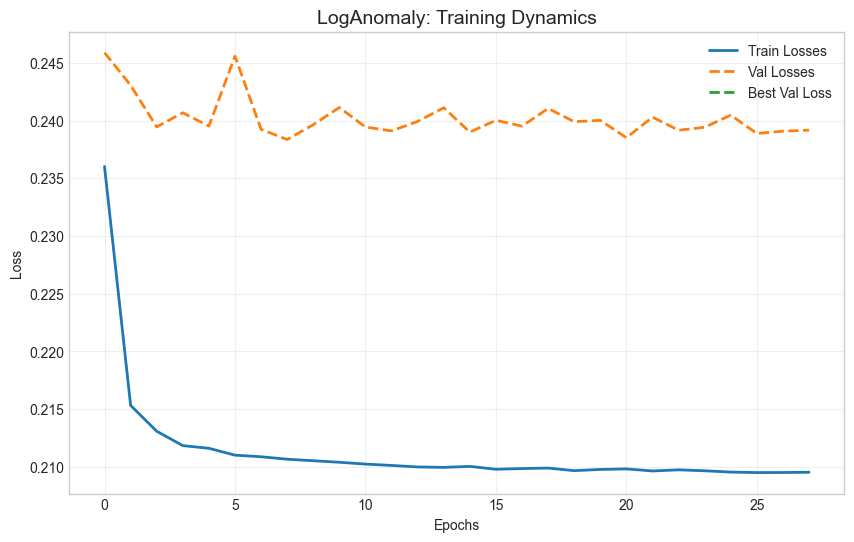

✓ Saved: ../figures/loganomaly/confusion_matrix.png


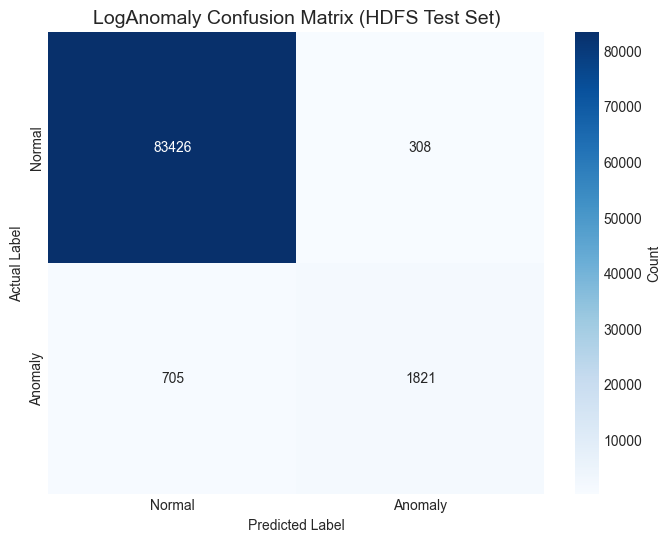

✓ Saved: ../figures/loganomaly/anomaly_score_distribution.png


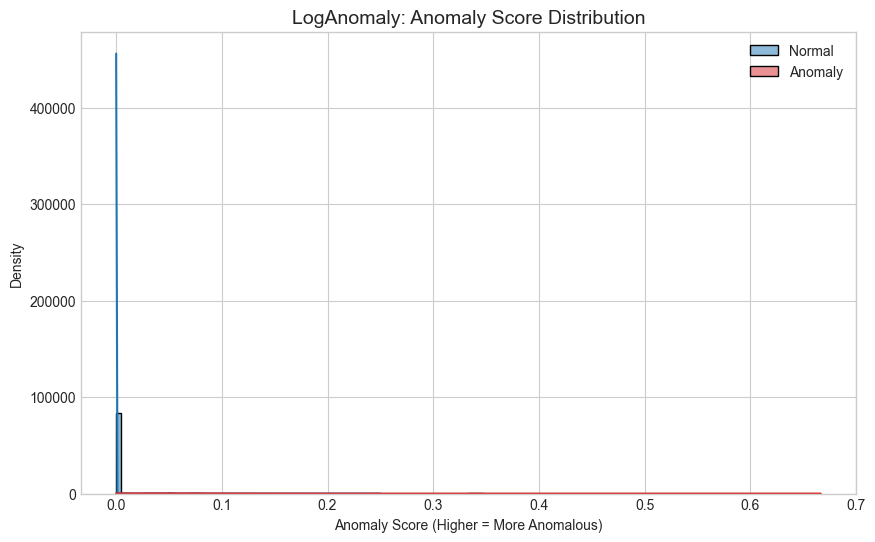

✓ Saved: ../figures/loganomaly/roc_curve.png


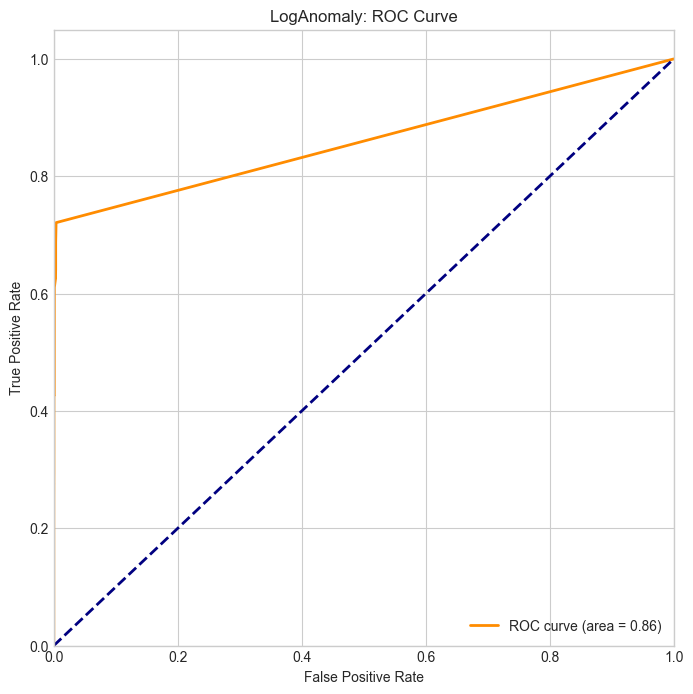

✓ Saved: ../figures/loganomaly/precision_recall_curve.png


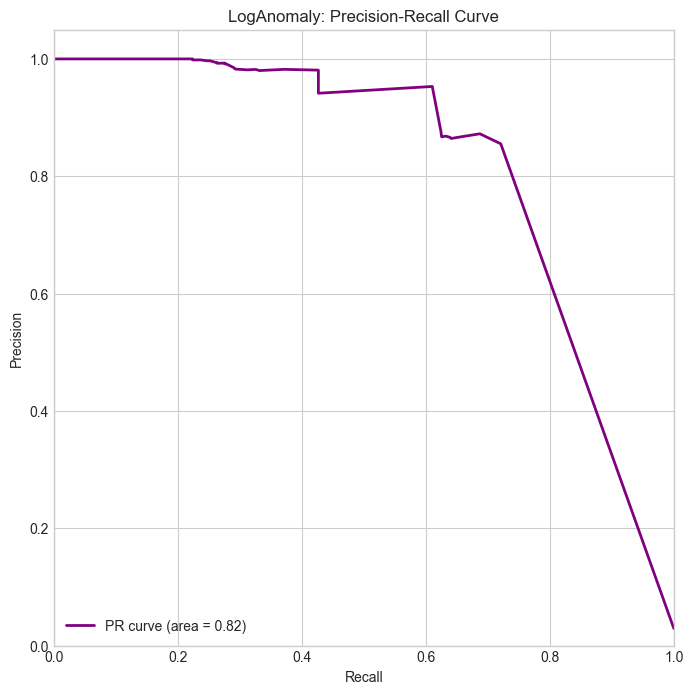


✓ All visualizations generated and saved using UniversalAnomalyVisualizer


In [ ]:
# Initialize visualizer with save directory
viz = UniversalAnomalyVisualizer(model_name="LogAnomaly", save_dir="../../figures/loganomaly")

# Plot 1: Training History (Loss curves)
viz.plot_training_history(history)

# Plot 2: Confusion Matrix
viz.plot_confusion_matrix(true_labels, predictions, title_suffix="(HDFS Test Set)")

# Plot 3: Anomaly Score Distribution
viz.plot_anomaly_score_distribution(true_labels, anomaly_scores, bins=50)

# Plot 4: ROC Curve
viz.plot_roc_curve(true_labels, anomaly_scores)

# Plot 5: Precision-Recall Curve
viz.plot_precision_recall_curve(true_labels, anomaly_scores)

print("\n✓ All visualizations generated and saved using UniversalAnomalyVisualizer")

### 7. Save Results and Model

In [28]:
# Save experiment results
save_experiment_results(
    filepath="../../results/hdfs_loganomaly_results.json",
    dataset="HDFS",
    model_name="LogAnomaly",
    device=device,
    model=model,
    history=history,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    max_len=max_len,
    metrics=metrics,
    batch_size=batch_size,
    learning_rate=learning_rate,
    patience=patience,
    top_k=top_k,
    # LogAnomaly-specific params
    use_attention=True,
    n_heads=4
)

✓ Results saved to ../../results/hdfs_loganomaly_results.json


{'dataset': 'HDFS',
 'model': 'LogAnomaly',
 'device': 'mps',
 'architecture': {'vocab_size': 29,
  'embedding_dim': 384,
  'hidden_dim': 128,
  'num_layers': 2,
  'dropout': 0.3,
  'use_attention': True,
  'num_attention_heads': 4},
 'training': {'num_epochs': 16,
  'batch_size': 64,
  'learning_rate': 0.001,
  'early_stopping_patience': 10,
  'best_val_loss': 0.23795490816943016,
  'training_time_seconds': 727.6855909824371},
 'data': {'train_size': 390756,
  'val_size': 86259,
  'test_size': 86260,
  'max_sequence_length': 28,
  'train_normal_only': True},
 'detection': {'top_k': 4, 'method': 'next_event_prediction'},
 'metrics': {'accuracy': 0.983909111987016,
  'precision': 0.8266360505166476,
  'recall': 0.5700712589073634,
  'f1': 0.6747891283973758,
  'confusion_matrix': [[83432, 302], [1086, 1440]]}}

In [ ]:
# Save model checkpoint
save_dir = Path('../mdls')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'loganomaly_checkpoint.pt'
trainer.save_model(str(save_path))

✓ Model saved to ../mdls/loganomaly_checkpoint.pt
